# SA Heart Prediction model - Decision tree

### Dataset - SA Heart

### Load Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn

In [3]:
saheart_df = pd.read_csv( "SAheart.csv" )

In [4]:
saheart_df.sample(5)

,row.names,sbp,tobacco,ldl,adiposity,famhist,typea,obesity,alcohol,age,chd
8,9,114,0.00,3.83,19.40,Present,49,24.86,2.49,29,0
45,46,128,4.65,3.31,22.74,Absent,62,22.95,0.51,48,0
118,119,150,3.50,6.99,25.39,Present,50,23.35,23.48,61,1
83,84,148,12.20,3.79,34.15,Absent,57,26.38,14.40,57,1
453,455,124,1.60,7.22,39.68,Present,36,31.50,0.00,51,1


In [5]:
saheart_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 462 entries, 0 to 461
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   row.names  462 non-null    int64  
 1   sbp        462 non-null    int64  
 2   tobacco    462 non-null    float64
 3   ldl        462 non-null    float64
 4   adiposity  462 non-null    float64
 5   famhist    462 non-null    object 
 6   typea      462 non-null    int64  
 7   obesity    456 non-null    float64
 8   alcohol    462 non-null    float64
 9   age        462 non-null    int64  
 10  chd        462 non-null    int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 39.8+ KB


In [ ]:
saheart_df.sample(10)

,row.names,sbp,tobacco,ldl,adiposity,famhist,typea,obesity,alcohol,age,chd
13,14,132,0.00,1.87,17.21,Absent,49,23.63,0.97,15,0
348,350,130,0.08,5.59,25.42,Present,50,24.98,6.27,43,1
56,57,118,0.00,2.99,16.17,Absent,49,23.83,3.22,28,0
437,439,138,0.06,4.15,20.66,Absent,49,22.59,2.49,16,0
289,291,112,0.60,5.28,25.71,Absent,55,27.02,27.77,38,1
63,64,140,0.45,4.30,24.33,Absent,41,27.23,10.08,38,0
425,427,132,0.00,3.30,21.61,Absent,42,24.92,32.61,33,0
333,335,152,19.45,4.22,29.81,Absent,28,23.95,0.00,59,1
337,339,138,6.00,7.24,37.05,Absent,38,28.69,0.00,59,0
321,323,146,4.36,4.31,18.44,Present,47,24.72,10.80,38,0


### Feature Set Selection

In [6]:
saheart_df.columns

Index(['row.names', 'sbp', 'tobacco', 'ldl', 'adiposity', 'famhist', 'typea',
       'obesity', 'alcohol', 'age', 'chd'],
      dtype='object')

In [7]:
x_features = ['sbp', 'tobacco', 'ldl', 'adiposity', 'famhist', 'typea',
       'obesity', 'alcohol', 'age']

In [8]:
cat_vars = ['famhist']

In [9]:
num_vars = list(set(x_features) - set(cat_vars))

In [10]:
num_vars

['age', 'typea', 'adiposity', 'ldl', 'alcohol', 'tobacco', 'obesity', 'sbp']

In [11]:
saheart_df[x_features].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 462 entries, 0 to 461
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sbp        462 non-null    int64  
 1   tobacco    462 non-null    float64
 2   ldl        462 non-null    float64
 3   adiposity  462 non-null    float64
 4   famhist    462 non-null    object 
 5   typea      462 non-null    int64  
 6   obesity    456 non-null    float64
 7   alcohol    462 non-null    float64
 8   age        462 non-null    int64  
dtypes: float64(5), int64(3), object(1)
memory usage: 32.6+ KB


### Need for Data Transformation

1. Data imputation for Seats Column
    - Mean imputation
2. Categorical Encoding for categorical columns
    - OHE Encoding
3. Data scaling
    - Standard scaling

### Setting X and y variables

In [12]:
X = saheart_df[x_features]
y = saheart_df['chd']

### Data Splitting - Train, Test and Prod (For Drift Monitoring)

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
# First, split into 90% (train+test) and 10% (prod)
train_test, prod = train_test_split(saheart_df, test_size=0.1, random_state=80)

# Then, split the remaining 90% into 70% train and 20% test
train, test = train_test_split(train_test, test_size=2/9, random_state=80)  # 2/9 ensures 20% of original data

In [17]:
train.to_parquet("train.parquet", index=False)
test.to_parquet("test.parquet", index=False)
prod.to_parquet("prod.parquet", index=False)

#### Defining Train dataset for model building

In [18]:
# 'chd' is the column to predict
X_train = train[x_features]
y_train = train["chd"]

In [19]:
X_train.shape

(322, 9)

In [20]:
y_train.shape

(322,)

#### Defining Test dataset for model evaluation

In [49]:
X_test = test[x_features]
y_test = test["chd"]

### Data Imputation

In [22]:
from sklearn.impute import KNNImputer

In [23]:
imputed_num_vars = ['obesity']

In [24]:
imputed_num_vars

['obesity']

In [25]:
non_imputed_num_vars = list(set(num_vars) - set(imputed_num_vars))

In [26]:
non_imputed_num_vars

['age', 'typea', 'adiposity', 'ldl', 'alcohol', 'tobacco', 'sbp']

In [27]:
knn_imputer = KNNImputer(n_neighbors=3)

### Mean Imputation

In [28]:
from sklearn.impute import SimpleImputer

In [29]:
mean_imputer = SimpleImputer(strategy='mean')

### Encode Categorical Variables

In [30]:
from sklearn.preprocessing import OneHotEncoder

In [31]:
ohe_encoder = OneHotEncoder(handle_unknown='ignore')

### Scaling numerical vars

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

### Creating Pipelines

- One preprocessing with KNN Imputer and other with Mean Imputer to later build Decision Tree for both the imputation

In [33]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [34]:
imputed_num_transformer = Pipeline( steps = [
        ('imputation', knn_imputer),
        ('scaler', scaler)])

In [35]:
imputed_num_transformer_2 = Pipeline( steps = [
        ('imputation', mean_imputer),
        ('scaler', scaler)])

In [36]:
non_imputed_num_transformer = Pipeline( steps = [('scaler', scaler)])

In [37]:
cat_transformer = Pipeline( steps = [('ohencoder', ohe_encoder)])

In [38]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num_imputed', imputed_num_transformer, imputed_num_vars),
        ('num_not_imputed', non_imputed_num_transformer, non_imputed_num_vars),
        ('catvars', cat_transformer, cat_vars)])

In [39]:
preprocessor_2 = ColumnTransformer(
    transformers=[
        ('num_imputed', imputed_num_transformer_2, imputed_num_vars),
        ('num_not_imputed', non_imputed_num_transformer, non_imputed_num_vars),
        ('catvars', cat_transformer, cat_vars)])

# Decision Tree
- One with KNN Imputer and GINI as impurity measure
- Other with Mean Imputer and ENTROPY as impurity measure


In [40]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

In [41]:
# Create Decision Tree Classifier
decision_tree = DecisionTreeClassifier(criterion='gini',
                                       max_depth=5,
                                       min_samples_split=2,
                                       min_samples_leaf=1)

In [42]:
# Create Decision Tree Classifier
decision_tree_2 = DecisionTreeClassifier(criterion='entropy',
                                       max_depth=5)

In [43]:
# Create Pipeline with Preprocessing and Decision Tree
dt_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('decision_tree', decision_tree)])


In [44]:
# Create Pipeline with Preprocessing and Decision Tree
dt_pipeline_2 = Pipeline(steps=[('preprocessor_2', preprocessor),
                              ('decision_tree_2', decision_tree)])


In [45]:
from sklearn import set_config
set_config(display='diagram')

In [46]:
dt_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num_imputed',
                                                  Pipeline(steps=[('imputation',
                                                                   KNNImputer(n_neighbors=3)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['obesity']),
                                                 ('num_not_imputed',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'typea', 'adiposity',
                                                   'ldl', 'alcohol', 'tobacco',
                                                   'sbp']),
                                                 ('catvars',
                                                  Pipeline(steps=[('ohencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['famhist'])])),
                ('decision_tree', DecisionTreeClassifier(max_depth=5))])

In [47]:
dt_pipeline_2.fit(X_train, y_train)

Pipeline(steps=[('preprocessor_2',
                 ColumnTransformer(transformers=[('num_imputed',
                                                  Pipeline(steps=[('imputation',
                                                                   KNNImputer(n_neighbors=3)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['obesity']),
                                                 ('num_not_imputed',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'typea', 'adiposity',
                                                   'ldl', 'alcohol', 'tobacco',
                                                   'sbp']),
                                                 ('catvars',
                                                  Pipeline(steps=[('ohencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['famhist'])])),
                ('decision_tree_2', DecisionTreeClassifier(max_depth=5))])

In [50]:
y_pred_dt = dt_pipeline.predict(X_test)

In [51]:
# Make predictions on the test set
y_pred_dt2 = dt_pipeline_2.predict(X_test)

### K Fold Cross Validation for Decision Tree

In [52]:
from sklearn.model_selection import cross_val_score

In [55]:
scores_dt1 = cross_val_score( dt_pipeline,
                          X_train,
                          y_train,
                          cv = 5,
                          scoring = 'recall')

In [58]:
# Mean Recall
scores_dt1.mean()

0.4228260869565218

In [59]:
# Standard Error
scores_dt1.std()

0.05329413335709244

In [54]:
scores_dt2 = cross_val_score( dt_pipeline_2,
                          X_train,
                          y_train,
                          cv = 5,
                          scoring = 'recall')

In [60]:
# Mean Recall
scores_dt2.mean()

0.4228260869565217

In [61]:
# Standard Error
scores_dt2.std()

0.06597387350214573

# Logistic Regression
- One with L1 regularization and other with L2 regularization

In [62]:
from sklearn.linear_model import LogisticRegression

In [67]:
# Define the Logistic Regression model with L1 regulrization
logistic_regression_l1 = LogisticRegression(penalty='l1',  # Regularization type
    solver='liblinear', # Algorithm to use in the optimization
    max_iter=100,  # Maximum number of iterations
   )

# Create the pipeline
pipeline_log_reg_l1 = Pipeline(steps=[('preprocessor', preprocessor),
                            ('classifier', logistic_regression_l1)])

# Fit the model
pipeline_log_reg_l1.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num_imputed',
                                                  Pipeline(steps=[('imputation',
                                                                   KNNImputer(n_neighbors=3)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['obesity']),
                                                 ('num_not_imputed',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'typea', 'adiposity',
                                                   'ldl', 'alcohol', 'tobacco',
                                                   'sbp']),
                                                 ('catvars',
                                                  Pipeline(steps=[('ohencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['famhist'])])),
                ('classifier',
                 LogisticRegression(penalty='l1', solver='liblinear'))])

In [68]:
# Define the Logistic Regression model with L2 regularization
logistic_regression_l2 = LogisticRegression(penalty='l2',  # Regularization type
    solver='lbfgs', # Algorithm to use in the optimization
    max_iter=100,  # Maximum number of iterations
   )

# Create the pipeline
pipeline_log_reg_l2 = Pipeline(steps=[('preprocessor', preprocessor),
                            ('classifier', logistic_regression_l2)])

# Fit the model
pipeline_log_reg_l2.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num_imputed',
                                                  Pipeline(steps=[('imputation',
                                                                   KNNImputer(n_neighbors=3)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['obesity']),
                                                 ('num_not_imputed',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'typea', 'adiposity',
                                                   'ldl', 'alcohol', 'tobacco',
                                                   'sbp']),
                                                 ('catvars',
                                                  Pipeline(steps=[('ohencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['famhist'])])),
                ('classifier', LogisticRegression())])

In [69]:
# Make predictions on the test set
y_pred_lr_l1 = pipeline_log_reg_l1.predict(X_test)

In [70]:
# Make predictions on the test set
y_pred_lr_l2 = pipeline_log_reg_l2.predict(X_test)

### K-Fold validation for Logistic Regression Models

In [71]:
scores_lreg_l1 = cross_val_score( pipeline_log_reg_l1,
                          X_train,
                          y_train,
                          cv = 5,
                          scoring = 'recall')

In [72]:
# Mean recall
scores_lreg_l1.mean()

0.6134057971014493

In [73]:
# Standard Error
scores_lreg_l1.std()

0.08226792158596932

In [74]:
scores_lreg_l2 = cross_val_score( pipeline_log_reg_l2,
                          X_train,
                          y_train,
                          cv = 5,
                          scoring = 'recall')

In [75]:
# Mean recall
scores_lreg_l2.mean()

0.596376811594203

In [76]:
# Standard Error
scores_lreg_l2.std()

0.09546534234999682

# Random Forest

In [78]:
from sklearn.ensemble import RandomForestClassifier

# Define the Random Forest model with hyperparameters
random_forest = RandomForestClassifier(
    n_estimators=100,        # Number of trees in the forest
    max_depth=5            # Maximum depth of the trees
)

# Create the pipeline
pipeline_rf = Pipeline(steps=[('preprocessor', preprocessor),
                            ('classifier', random_forest)])

# Fit the model
pipeline_rf.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num_imputed',
                                                  Pipeline(steps=[('imputation',
                                                                   KNNImputer(n_neighbors=3)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['obesity']),
                                                 ('num_not_imputed',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'typea', 'adiposity',
                                                   'ldl', 'alcohol', 'tobacco',
                                                   'sbp']),
                                                 ('catvars',
                                                  Pipeline(steps=[('ohencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['famhist'])])),
                ('classifier', RandomForestClassifier(max_depth=5))])

In [79]:
# Make predictions on the test set
y_pred_rf = pipeline_rf.predict(X_test)

### K-Fold validation for Random Forest Model

In [80]:
scores_rf = cross_val_score( pipeline_rf,
                          X_train,
                          y_train,
                          cv = 5,
                          scoring = 'recall')

In [81]:
# Mean recall
scores_rf.mean()

0.45724637681159425

In [82]:
# Standard Error
scores_rf.std()

0.07233321573024798

# WANDB logging

In [93]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error
import wandb
import os

In [94]:
os.environ["WANDB_API_KEY"] = "0bea1d0fcbb8912086510be34b0601c8b672cb58"

### Log Decision Tree-1

In [95]:
from sklearn.metrics import roc_auc_score, recall_score

In [99]:
wandb.init(project='mlops_SAheart', config=None, tags = ['Decision Tree Model', 'KNN Imputer', 'Gini'])
wandb.run.name = "DecisionTree-1"
roc_auc = roc_auc_score(y_test, dt_pipeline.predict_proba(X_test)[:, 1])
recall = recall_score(y_test, y_pred_dt)

wandb.log( {"roc_auc_score" : roc_auc_score,
            "recall": recall,
            "mean_recall": scores.mean(),
            "std_recall":scores.std()} )

wandb.Artifact("DecisionTree",
               type = 'model',
               description = None)

wandb.save()
wandb.finish()

mean_recall,▁
recall,▁
std_recall,▁
mean_recall,0.41413
recall,0.35294
roc_auc_score,sklearn.metrics._ran...
std_recall,0.06075


### Log Decision Tree-2

In [100]:
wandb.init(project='mlops_SAheart', config=None, tags = ['Decision Tree Model', 'Mean Imputer', 'Entropy'])
wandb.run.name = "DecisionTree-2"
roc_auc = roc_auc_score(y_test, dt_pipeline_2.predict_proba(X_test)[:, 1])
recall = recall_score(y_test, y_pred_dt2)

wandb.log( {"roc_auc_score" : roc_auc_score,
            "recall": recall,
            "mean_recall": scores_dt2.mean(),
            "std_recall":scores_dt2.std()}  )

wandb.Artifact("DecisionTree-2",
               type = 'model',
               description = None)

wandb.save()
wandb.finish()

mean_recall,▁
recall,▁
std_recall,▁
mean_recall,0.42283
recall,0.35294
roc_auc_score,sklearn.metrics._ran...
std_recall,0.06597


### Log Logistic Regression-1

In [102]:
wandb.init(project='mlops_SAheart', config=None, tags = ['Logistic Regression Model', 'KNN Imputer', 'L1 Penaulty'])
wandb.run.name = "LogisticRegression-L1"
roc_auc = roc_auc_score(y_test, pipeline_log_reg_l1.predict_proba(X_test)[:, 1])
recall = recall_score(y_test, y_pred_lr_l1)

wandb.log( {"roc_auc_score" : roc_auc_score,
            "recall": recall,
            "mean_recall": scores_lreg_l1.mean(),
            "std_recall":scores_lreg_l1.std()} )

wandb.Artifact("LogisticRegression",
               type = 'model',
               description = None)

wandb.save()
wandb.finish()

mean_recall,▁
recall,▁
std_recall,▁
mean_recall,0.61341
recall,0.41176
roc_auc_score,sklearn.metrics._ran...
std_recall,0.08227


### Log Logistic Regression-2

In [103]:
wandb.init(project='mlops_SAheart', config=None, tags = ['Logistic Regression Model', 'KNN Imputer', 'L2 Penaulty'])
wandb.run.name = "LogisticRegression-L2"
roc_auc = roc_auc_score(y_test, pipeline_log_reg_l2.predict_proba(X_test)[:, 1])
recall = recall_score(y_test, y_pred_lr_l2)

wandb.log( {"roc_auc_score" : roc_auc_score,
            "recall": recall,
            "mean_recall": scores_lreg_l2.mean(),
            "std_recall":scores_lreg_l2.std()} )

wandb.Artifact("LogisticRegression",
               type = 'model',
               description = None)

wandb.save()
wandb.finish()

mean_recall,▁
recall,▁
std_recall,▁
mean_recall,0.59638
recall,0.41176
roc_auc_score,sklearn.metrics._ran...
std_recall,0.09547


### Log Random Forest

In [104]:
wandb.init(project='mlops_SAheart', config=None, tags = ['Random Forest Model', 'KNN Imputer'])
wandb.run.name = "RandomForest"
roc_auc = roc_auc_score(y_test, pipeline_rf.predict_proba(X_test)[:, 1])
recall = recall_score(y_test, y_pred_rf)

wandb.log( {"roc_auc_score" : roc_auc_score,
            "recall": recall,
            "mean_recall": scores_rf.mean(),
            "std_recall":scores_rf.std()} )

wandb.Artifact("RandomForest",
               type = 'model',
               description = None)

wandb.save()
wandb.finish()

mean_recall,▁
recall,▁
std_recall,▁
mean_recall,0.45725
recall,0.35294
roc_auc_score,sklearn.metrics._ran...
std_recall,0.07233


# Save PKL file
- Best one seems to be Logistic regression with L1 regularization
- It has Recall of 0.61 and Standard Error 0.08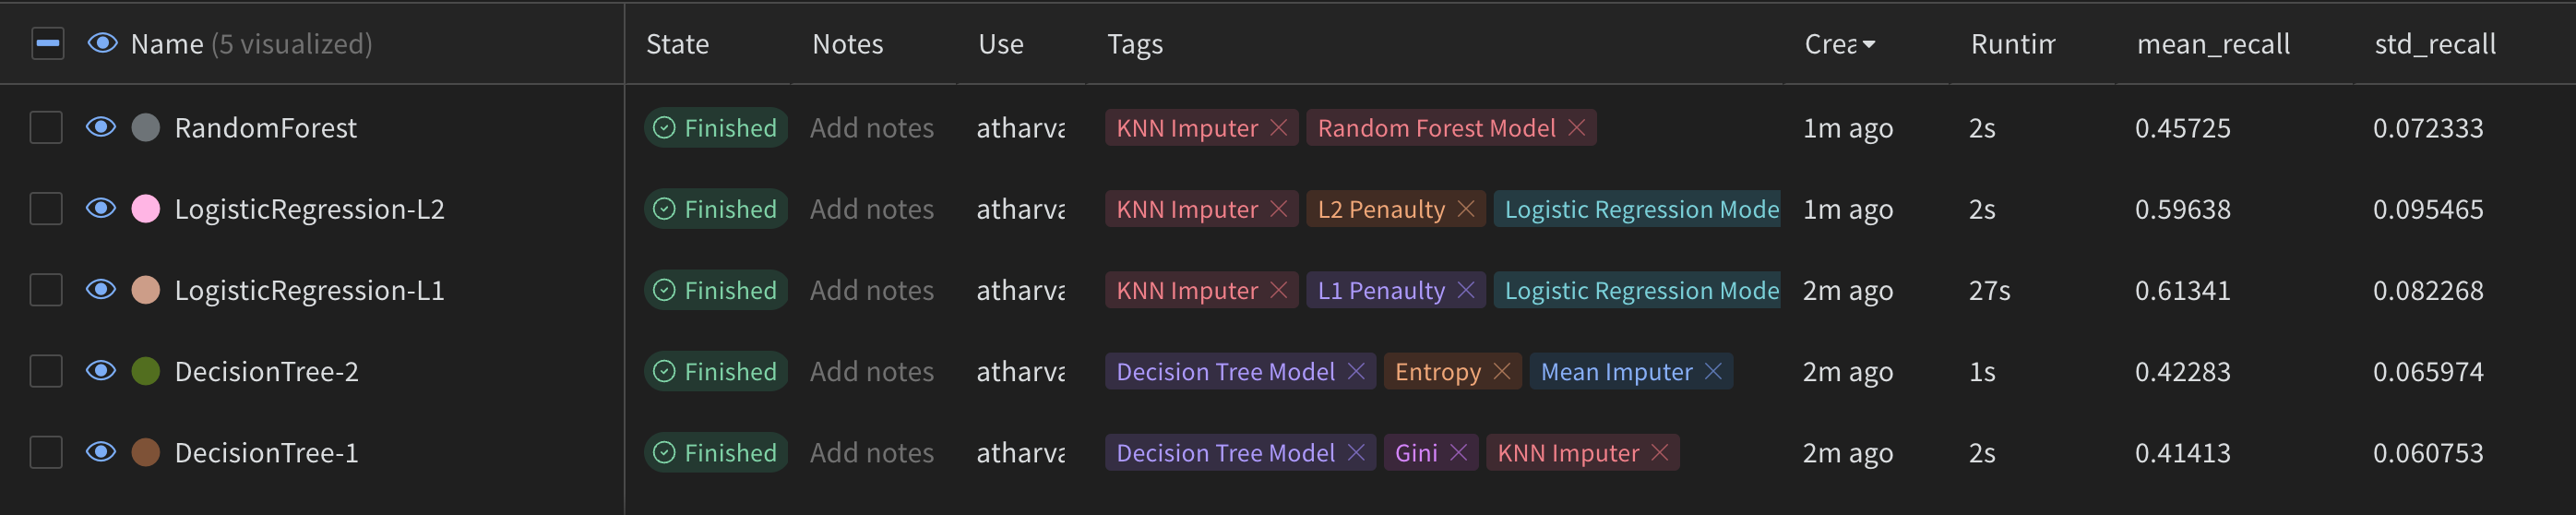

In [83]:
from joblib import dump

In [85]:
dump(pipeline_log_reg_l1, "heart_lr_model.pkl")

['heart_lr_model.pkl']

# Now load Heart.pkl model to predict and test on real data

In [86]:
import joblib

In [87]:
# Upload heart.pkl in the files first
pipeline = joblib.load('heart_lr_model.pkl')

In [88]:
pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num_imputed',
                                                  Pipeline(steps=[('imputation',
                                                                   KNNImputer(n_neighbors=3)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['obesity']),
                                                 ('num_not_imputed',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'typea', 'adiposity',
                                                   'ldl', 'alcohol', 'tobacco',
                                                   'sbp']),
                                                 ('catvars',
                                                  Pipeline(steps=[('ohencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['famhist'])])),
                ('classifier',
                 LogisticRegression(penalty='l1', solver='liblinear'))])

In [89]:
sa_heart = {
"sbp": 160,
"tobacco": 12,
"ldl": 5.73,
"adiposity": 23.11,
"famhist": "Present",
"typea": 49,
"obesity": 25.3,
"alcohol": 97.2,
"age": 52}

In [90]:
sa_heart_df = pd.DataFrame([sa_heart], index=[0])

In [92]:
# This is correct
pipeline.predict(sa_heart_df)

array([1])